# 02 - Titanic modeling pipeline

Module 2, Part B. This notebook continues from `01_eda.ipynb`. It reads the **same committed
`titanic.csv`** that notebook saved and never calls `sns.load_dataset` again.

The Task 2 structural cleaning decisions are re-applied here because they don't learn anything
from the data:
drop the 2 rows missing `embarked`, and leave `deck` out.

The Task 2 **age imputation is deliberately not re-used**. It computed group medians over the
full dataset, which would leak test-set information into training. Here, age imputation lives
inside the pipeline and is fit on the training split only.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay, accuracy_score, confusion_matrix,
                             f1_score, mean_absolute_error, mean_squared_error, precision_score,
                             r2_score, recall_score, roc_auc_score)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

sns.set_theme(style="whitegrid", context="notebook")
SEED = 42
FIG = Path("figures")
MODELS = Path("models")
FIG.mkdir(exist_ok=True)
MODELS.mkdir(exist_ok=True)

def save(fig, name):
    fig.savefig(FIG / name, dpi=110, bbox_inches="tight")

In [2]:
df = pd.read_csv("titanic.csv")                      # same file 01_eda.ipynb produced
df = df.dropna(subset=["embarked"])                  # Task 2 rule: < 5% missing -> drop rows

NUMERIC = ["pclass", "age", "sibsp", "parch", "fare"]
CATEGORICAL = ["sex", "embarked"]
FEATURES = NUMERIC + CATEGORICAL
TARGET = "survived"

# Deliberately excluded: 'alive' (the target as text - pure leakage), 'class' / 'embark_town' / 'who'
# (duplicates of pclass / embarked / sex+age), 'adult_male' / 'alone' (derived flags), 'deck' (77% missing).
X, y = df[FEATURES], df[TARGET]
print(X.shape)
print(y.value_counts().to_string())
print((y.value_counts(normalize=True) * 100).round(2).to_string())

(889, 7)
survived
0    549
1    340
survived
0    61.75
1    38.25


## Task 7 - Stratified train/test split (before any preprocessing)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)

split_balance = pd.DataFrame({
    "full": y.value_counts(normalize=True),
    "train": y_train.value_counts(normalize=True),
    "test": y_test.value_counts(normalize=True),
}).round(4)
print(len(X_train), "train rows /", len(X_test), "test rows")
split_balance

711 train rows / 178 test rows


,full,train,test
survived,,,
0,0.6175,0.6174,0.618
1,0.3825,0.3826,0.382


**Why stratify.** The target is imbalanced: 61.75% died vs 38.25% survived (549 vs 340 after
dropping the 2 rows with no `embarked`). An unstratified 80/20 split of 889 rows could, by
chance, give a test set with noticeably more or fewer survivors, which would skew every test
metric, especially precision and recall for the minority *survived* class. With
`stratify=y`, both splits keep the original ratio: **train 38.26% survived, test 38.20%**. The
178-row test set is then a fair miniature of the population. The split happens **before** any
imputation, encoding or scaling.

## Task 8 - Preprocessing, fit on the training split only

One `ColumnTransformer` does per-column imputation, encoding and scaling. It sits inside a
`Pipeline` with each estimator, so `pipeline.fit(X_train, y_train)` fits the imputers, encoder
and scaler on training rows only. `predict(X_test)` then only calls `transform` on the test
rows. The pipeline structure enforces the separation; nothing depends on remembering it by hand.

| Columns | Steps | Why |
|---|---|---|
| `pclass`, `age`, `sibsp`, `parch`, `fare` | `SimpleImputer(median)` -> `StandardScaler` | Median is robust to the skew in `fare`/`age`; only `age` actually has gaps (~20%) but the imputer protects against missing values in any future raw input. `pclass` is kept as an ordinal number (1 < 2 < 3). |
| `sex`, `embarked` | `SimpleImputer(most_frequent)` -> `OneHotEncoder(handle_unknown="ignore")` | One-hot avoids implying an order between ports; `handle_unknown="ignore"` keeps the saved pipeline from crashing on an unseen category. |

In [4]:
def make_preprocessor():
    numeric = Pipeline([("impute", SimpleImputer(strategy="median")),
                        ("scale", StandardScaler())])
    categorical = Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                            ("onehot", OneHotEncoder(handle_unknown="ignore"))])
    return ColumnTransformer([("num", numeric, NUMERIC), ("cat", categorical, CATEGORICAL)])

def make_pipeline(estimator):
    return Pipeline([("prep", make_preprocessor()), ("clf", estimator)])

# demonstration: the fitted scaler's statistics come from training rows only
demo = make_preprocessor().fit(X_train)
scaler = demo.named_transformers_["num"].named_steps["scale"]
imputer = demo.named_transformers_["num"].named_steps["impute"]
print("imputer medians (train):", dict(zip(NUMERIC, imputer.statistics_.round(2))))
print("scaler means    (train):", dict(zip(NUMERIC, scaler.mean_.round(2))))
print("age median of test rows, NOT used:", X_test["age"].median())
print("output features:", list(demo.get_feature_names_out()))

imputer medians (train): {'pclass': np.float64(3.0), 'age': np.float64(28.0), 'sibsp': np.float64(0.0), 'parch': np.float64(0.0), 'fare': np.float64(14.4)}
scaler means    (train): {'pclass': np.float64(2.32), 'age': np.float64(29.4), 'sibsp': np.float64(0.5), 'parch': np.float64(0.38), 'fare': np.float64(31.86)}
age median of test rows, NOT used: 28.0
output features: ['num__pclass', 'num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S']


## Task 9 - Three classifiers on the identical split

In [5]:
models = {
    "Logistic Regression": make_pipeline(LogisticRegression(max_iter=1000, random_state=SEED)),
    "Decision Tree": make_pipeline(DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=SEED)),
    "Random Forest": make_pipeline(RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1)),
}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    print(f"fitted {name}")

fitted Logistic Regression
fitted Decision Tree


fitted Random Forest


The Decision Tree is capped at `max_depth=4` (with `min_samples_leaf=5`). An unconstrained tree
memorizes the training set, and a depth-4 tree is also small enough for `plot_tree` to stay
readable.

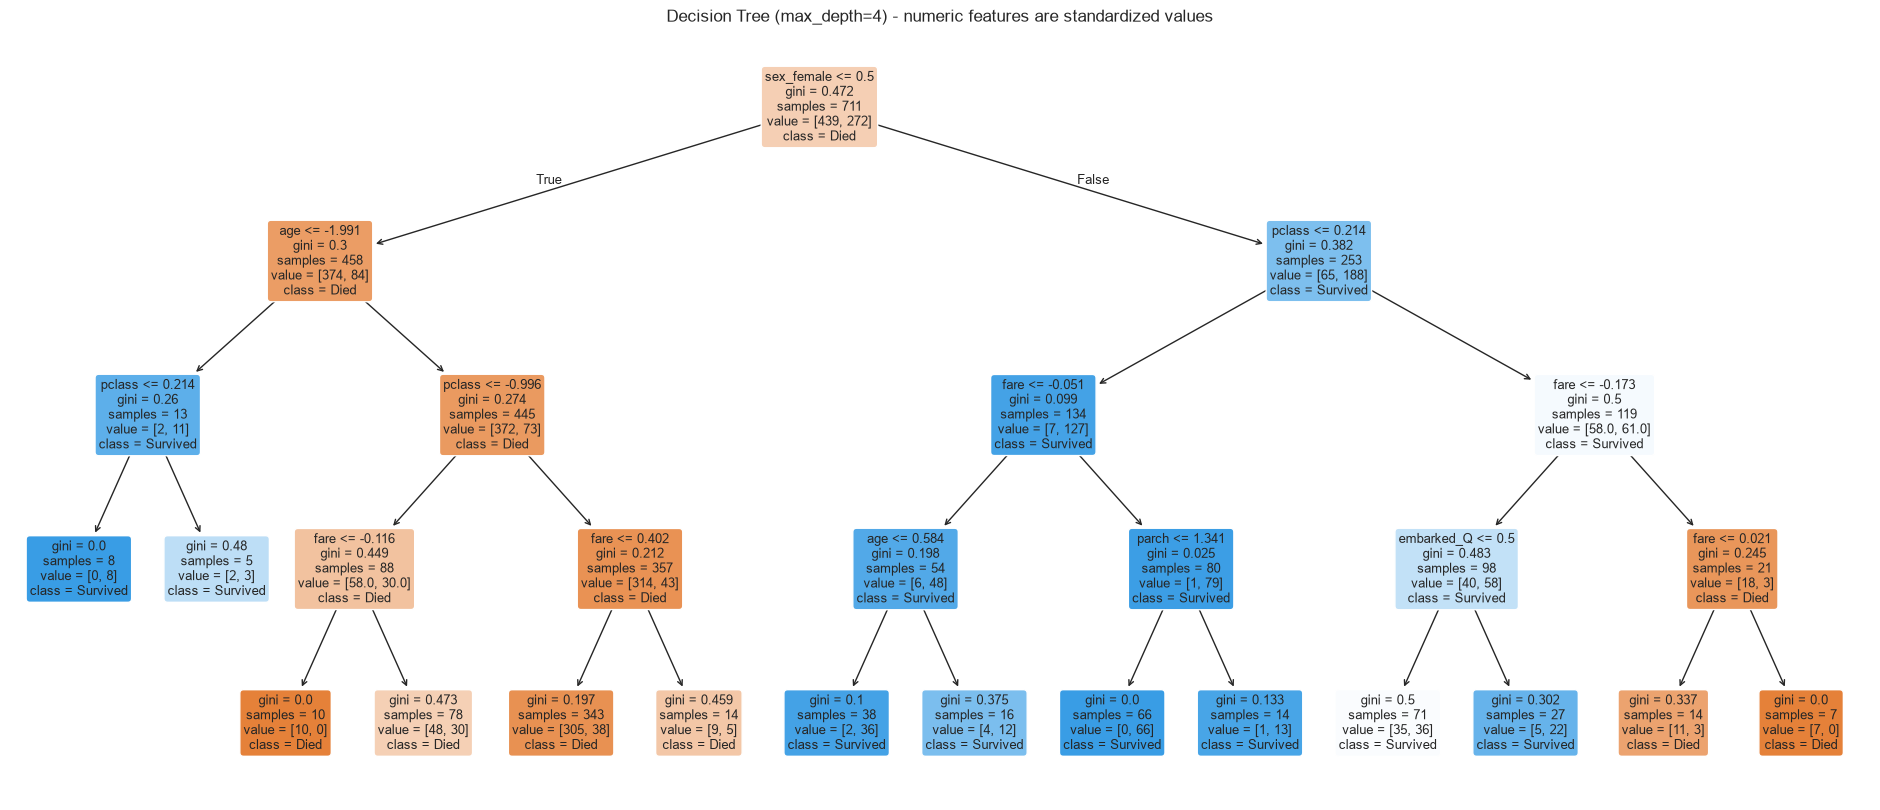

In [6]:
tree_pipe = models["Decision Tree"]
feature_names = [n.split("__", 1)[1] for n in tree_pipe.named_steps["prep"].get_feature_names_out()]

fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(tree_pipe.named_steps["clf"], feature_names=feature_names, class_names=["Died", "Survived"],
          filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title("Decision Tree (max_depth=4) - numeric features are standardized values")
save(fig, "09_decision_tree.png")
plt.show()

**Reading the tree.** Numeric thresholds are on standardized values; for example,
`pclass <= 0.21` means `pclass <= 2.49`, i.e. 1st or 2nd class. The root split is `sex_female`,
which carries 63% of the tree's feature importance. Women in 1st/2nd class go to leaves that
predict *Survived*. For men, the next split is `age <= -1.99` (about 3.5 years old), then class.
The tree rediscovers the EDA story on its own: sex first, then class and childhood, with
`pclass` at 19.5% importance and `age` and `fare` at about 8% each.

## Task 10 - Evaluation: confusion matrix, accuracy, precision, recall, F1, ROC/AUC

In [7]:
def evaluate(pipe, X_eval=X_test, y_eval=y_test):
    pred = pipe.predict(X_eval)
    proba = pipe.predict_proba(X_eval)[:, 1]
    return {"accuracy": accuracy_score(y_eval, pred), "precision": precision_score(y_eval, pred),
            "recall": recall_score(y_eval, pred), "f1": f1_score(y_eval, pred),
            "roc_auc": roc_auc_score(y_eval, proba)}

results = pd.DataFrame({name: evaluate(pipe) for name, pipe in models.items()}).T.round(4)
results

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.8090,0.7833,0.6912,0.7344,0.8610
Decision Tree,0.7978,0.7759,0.6618,0.7143,0.8510
Random Forest,0.8034,0.7619,0.7059,0.7328,0.8237


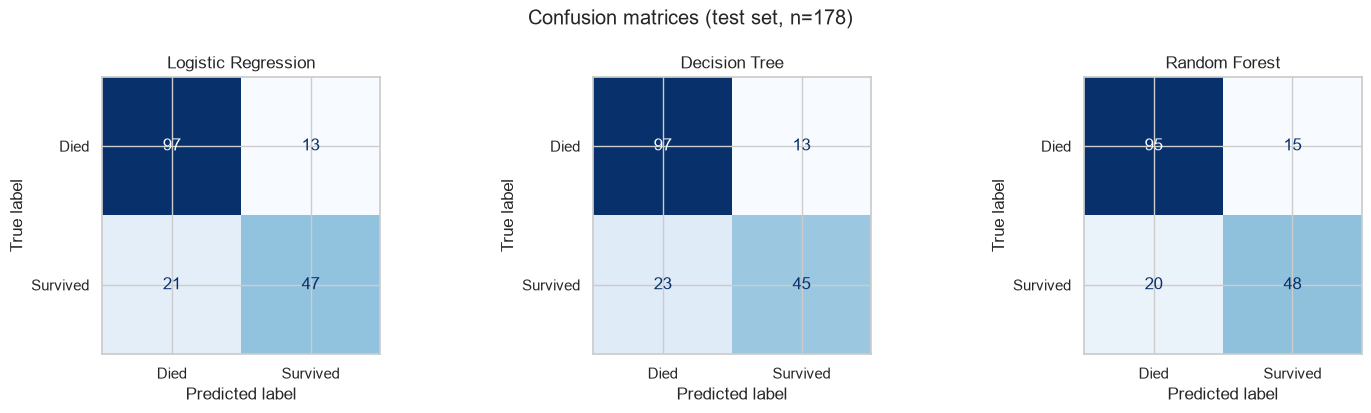

Logistic Regression  TN= 97 FP= 13 FN= 21 TP= 47
Decision Tree        TN= 97 FP= 13 FN= 23 TP= 45
Random Forest        TN= 95 FP= 15 FN= 20 TP= 48


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (name, pipe) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_estimator(pipe, X_test, y_test, display_labels=["Died", "Survived"],
                                          cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(name)
fig.suptitle("Confusion matrices (test set, n=%d)" % len(y_test))
fig.tight_layout()
save(fig, "10_confusion_matrices.png")
plt.show()

for name, pipe in models.items():
    tn, fp, fn, tp = confusion_matrix(y_test, pipe.predict(X_test)).ravel()
    print(f"{name:20s} TN={tn:3d} FP={fp:3d} FN={fn:3d} TP={tp:3d}")

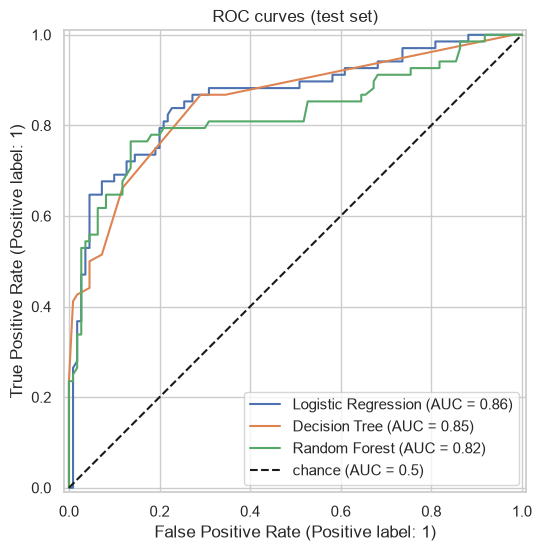

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, pipe in models.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, name=name, ax=ax)
ax.plot([0, 1], [0, 1], "k--", label="chance (AUC = 0.5)")
ax.set_title("ROC curves (test set)")
ax.legend(loc="lower right")
save(fig, "11_roc_curves.png")
plt.show()

In [10]:
# side-by-side comparison table: confusion-matrix counts + every metric
cm_cols = {}
for name, pipe in models.items():
    tn, fp, fn, tp = confusion_matrix(y_test, pipe.predict(X_test)).ravel()
    cm_cols[name] = {"TN": tn, "FP": fp, "FN": fn, "TP": tp}
comparison = pd.concat([pd.DataFrame(cm_cols).T, results], axis=1)
comparison

,TN,FP,FN,TP,accuracy,precision,recall,f1,roc_auc
Logistic Regression,97,13,21,47,0.8090,0.7833,0.6912,0.7344,0.8610
Decision Tree,97,13,23,45,0.7978,0.7759,0.6618,0.7143,0.8510
Random Forest,95,15,20,48,0.8034,0.7619,0.7059,0.7328,0.8237


**Reading the results.**
- **Logistic Regression:** best **ROC AUC (0.861)** and best precision among the three
  untuned models (0.783).
- **Random Forest (default):** catches slightly more survivors (recall 0.706, 48 TP) at the
  cost of more false alarms (15 FP), and has the lowest AUC (0.824). With no depth limit its
  trees overfit.
- **Decision Tree (depth 4):** close behind at accuracy 0.798 and AUC 0.851. It's a strong
  result for such a small, fully interpretable model.

All three sit at roughly 80% accuracy. Every model misses 20-23 of the 68 survivors, so recall
is the weak spot, consistent with survivors being the minority class.

## Task 11 - Class-imbalance handling (Logistic Regression, three ways)

In [11]:
print("training-set class balance:")
print(y_train.value_counts().rename(index={0: "died", 1: "survived"}).to_string())
print(f"ratio died:survived = {(y_train == 0).sum() / (y_train == 1).sum():.2f} : 1")

training-set class balance:
survived
died        439
survived    272
ratio died:survived = 1.61 : 1


In [12]:
variants = {
    "(a) baseline": make_pipeline(LogisticRegression(max_iter=1000, random_state=SEED)),
    "(b) class_weight='balanced'": make_pipeline(
        LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)),
    # imblearn's Pipeline applies SMOTE only during fit(), i.e. only to training rows;
    # predict() on the test set skips the sampler entirely.
    "(c) SMOTE (train fold only)": ImbPipeline([
        ("prep", make_preprocessor()),
        ("smote", SMOTE(random_state=SEED)),
        ("clf", LogisticRegression(max_iter=1000, random_state=SEED))]),
}
for pipe in variants.values():
    pipe.fit(X_train, y_train)

smote_pipe = variants["(c) SMOTE (train fold only)"]
Xt = smote_pipe.named_steps["prep"].transform(X_train)
_, y_res = smote_pipe.named_steps["smote"].fit_resample(Xt, y_train)
print("training labels after SMOTE:", np.bincount(y_res), "| test labels untouched:", np.bincount(y_test))

imbalance = pd.DataFrame({n: evaluate(p) for n, p in variants.items()}).T[["precision", "recall", "f1"]]

# a single 179-row test set is noisy, so also report 5-fold stratified CV on the training split
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
for n, p in variants.items():
    f1s, recs = [], []
    for tr, va in cv.split(X_train, y_train):
        p.fit(X_train.iloc[tr], y_train.iloc[tr])
        pr = p.predict(X_train.iloc[va])
        f1s.append(f1_score(y_train.iloc[va], pr)); recs.append(recall_score(y_train.iloc[va], pr))
    imbalance.loc[n, "cv_recall"] = np.mean(recs)
    imbalance.loc[n, "cv_f1"] = np.mean(f1s)
    p.fit(X_train, y_train)                            # refit on the full training split
imbalance.round(4)

training labels after SMOTE: [439 439] | test labels untouched: [110  68]


,precision,recall,f1,cv_recall,cv_f1
(a) baseline,0.7833,0.6912,0.7344,0.6910,0.7100
(b) class_weight='balanced',0.7183,0.7500,0.7338,0.7609,0.7269
(c) SMOTE (train fold only),0.7353,0.7353,0.7353,0.7535,0.7278


**Class balance (training split):** 439 died vs 272 survived (1.61 : 1). SMOTE, applied only
inside `fit()` on the training rows, balances them to 439 : 439. The 178 test rows are never
resampled.

**Conclusion.** Both imbalance strategies traded precision for recall, exactly as expected.
- **Recall on the minority *survived* class:** rose from 0.691 (baseline) to **0.750** with
  `class_weight='balanced'` and 0.735 with SMOTE.
- **Precision:** fell from 0.783 to 0.718 and 0.735.
- **Test-set F1:** nearly identical across all three (0.734 / 0.734 / 0.735), so a single
  178-row test set can't separate them.
- **5-fold CV on the training split:** here both strategies clearly beat the baseline (CV F1
  0.710 -> 0.727 / 0.728, CV recall 0.691 -> 0.761 / 0.754).

**`class_weight='balanced'` worked best overall.** It gives the highest recall on both test
and CV, and effectively ties SMOTE on F1. It's also simpler: it reweights the loss instead of
creating synthetic passengers, so it adds no interpolated rows that may not look like real
people.

The imbalance here is mild (1.6 : 1), which is why the gains are modest. Which variant to
prefer depends on the cost of errors: if missing a survivor is costlier than a false alarm,
use the balanced weights.

## Task 12 - Hyperparameter tuning: GridSearchCV over the Random Forest (with OOB score)

In [13]:
rf_pipe = make_pipeline(RandomForestClassifier(oob_score=True, random_state=SEED, n_jobs=-1))
param_grid = {
    "clf__n_estimators": [100, 200, 400],
    "clf__max_depth": [4, 6, 8, None],
    "clf__max_features": ["sqrt", "log2", None],
}
grid = GridSearchCV(rf_pipe, param_grid, cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                    scoring="f1", n_jobs=-1)
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_                      # refit on the whole training split
print("best parameters:", grid.best_params_)
print(f"best 5-fold CV F1: {grid.best_score_:.4f}")
print(f"OOB score (accuracy on out-of-bag training rows): {best_rf.named_steps['clf'].oob_score_:.4f}")

best parameters: {'clf__max_depth': 8, 'clf__max_features': None, 'clf__n_estimators': 400}
best 5-fold CV F1: 0.7722
OOB score (accuracy on out-of-bag training rows): 0.8326


In [14]:
cvres = pd.DataFrame(grid.cv_results_)
cvres[["param_clf__n_estimators", "param_clf__max_depth", "param_clf__max_features",
       "mean_test_score", "rank_test_score"]].sort_values("rank_test_score").head(8).round(4)

,param_clf__n_estimators,param_clf__max_depth,param_clf__max_features,mean_test_score,rank_test_score
26,400,8,NaN,0.7722,1
24,100,8,NaN,0.7685,2
21,100,8,log2,0.7628,3
18,100,8,sqrt,0.7628,3
35,400,None,NaN,0.7627,5
23,400,8,log2,0.7621,6
20,400,8,sqrt,0.7621,6
33,100,None,NaN,0.7604,8


In [15]:
results.loc["Random Forest (tuned)"] = pd.Series(evaluate(best_rf)).round(4)
results

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.8090,0.7833,0.6912,0.7344,0.8610
Decision Tree,0.7978,0.7759,0.6618,0.7143,0.8510
Random Forest,0.8034,0.7619,0.7059,0.7328,0.8237
Random Forest (tuned),0.8315,0.8276,0.7059,0.7619,0.8406


**Tuning result.**
- **Search:** `GridSearchCV` tried 3 x 4 x 3 = 36 combinations with 5-fold stratified CV,
  scored by F1, all on the training split.
- **Best parameters:** **`n_estimators=400`, `max_depth=8`, `max_features=None`**.
- **Scores:** best mean CV F1 **0.772**. The refitted best forest, built with
  `RandomForestClassifier(oob_score=True, ...)`, reports an **OOB score of 0.833**: accuracy
  on the training rows each tree didn't see in its bootstrap sample, so a free internal
  validation estimate.
- **Why these parameters won:** capping depth at 8 stops the trees from memorizing the data,
  unlike the default forest's unlimited depth. `max_features=None` lets every split consider
  all features, which helps when one feature, `sex`, dominates.
- **Test set:** the tuned forest improves to **accuracy 0.831, precision 0.828, F1 0.762,
  AUC 0.841**, beating the default forest on every metric except recall, where they tie. Its
  test accuracy (0.831) also closely matches the OOB estimate (0.833), a sign it is not
  overfitting.

## Task 13 - Regression side-task: predict `fare` with multivariate linear regression

Features: `pclass`, `sex`, `age`, `sibsp`, `parch`, `embarked`. `survived` is left out: it's an
outcome of the voyage, not something that could set the ticket price. The train/test rows are
the same as in the classification split, and the same fit-on-train preprocessor is used.

In [16]:
REG_NUMERIC = ["pclass", "age", "sibsp", "parch"]
reg_prep = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), REG_NUMERIC),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))]), CATEGORICAL),
])
reg = Pipeline([("prep", reg_prep), ("lr", LinearRegression())])

Xr_train, Xr_test = X_train.drop(columns="fare"), X_test.drop(columns="fare")
fr_train, fr_test = X_train["fare"], X_test["fare"]
reg.fit(Xr_train, fr_train)
fare_pred = reg.predict(Xr_test)

n, p = len(fr_test), len(reg.named_steps["prep"].get_feature_names_out())
r2 = r2_score(fr_test, fare_pred)
reg_metrics = pd.Series({
    "MSE": mean_squared_error(fr_test, fare_pred),
    "MAE": mean_absolute_error(fr_test, fare_pred),
    "RMSE": np.sqrt(mean_squared_error(fr_test, fare_pred)),
    "R2": r2,
    "Adjusted R2": 1 - (1 - r2) * (n - 1) / (n - p - 1),
}, name="Linear Regression (fare)").round(4)
print(f"n = {n} test rows, p = {p} predictors after encoding")
reg_metrics

n = 178 test rows, p = 7 predictors after encoding


MSE            1702.6149
MAE              19.6457
RMSE             41.2628
R2                0.3474
Adjusted R2       0.3205
Name: Linear Regression (fare), dtype: float64

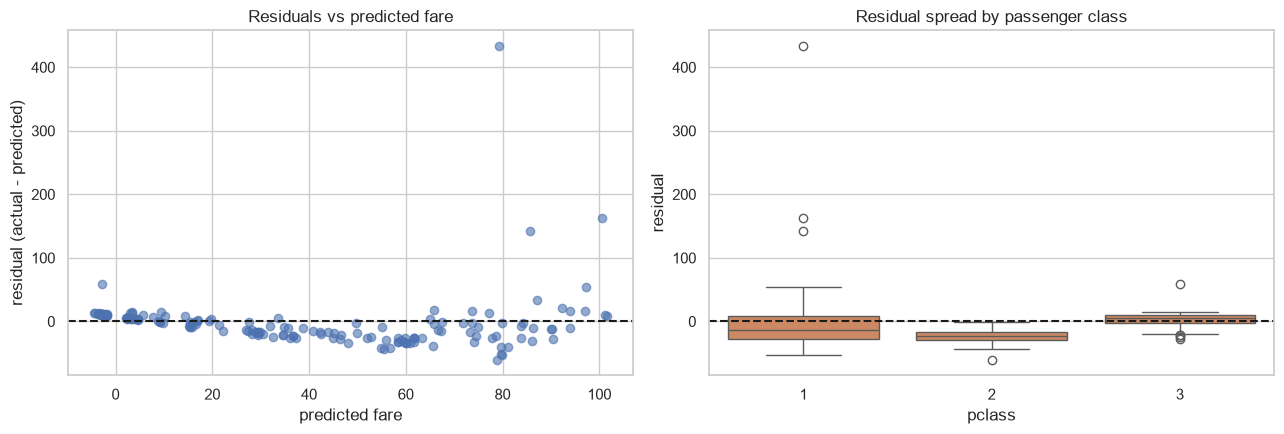

residual std by predicted-fare band:
            mean    std
pred_band              
low         9.61   7.33
mid        14.41   9.07
high       35.17  59.38
Spearman corr(|residual|, predicted): 0.439


In [17]:
resid = fr_test - fare_pred
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(fare_pred, resid, alpha=0.6, color="#4C72B0")
axes[0].axhline(0, color="k", ls="--")
axes[0].set(title="Residuals vs predicted fare", xlabel="predicted fare", ylabel="residual (actual - predicted)")
sns.boxplot(x=X_test["pclass"], y=resid, ax=axes[1], color="#DD8452")
axes[1].axhline(0, color="k", ls="--")
axes[1].set(title="Residual spread by passenger class", ylabel="residual")
fig.tight_layout()
save(fig, "12_regression_residuals.png")
plt.show()

spread = pd.DataFrame({"pred": fare_pred, "abs_resid": resid.abs().values})
spread["pred_band"] = pd.qcut(spread["pred"], 3, labels=["low", "mid", "high"])
print("residual std by predicted-fare band:")
print(spread.groupby("pred_band", observed=True)["abs_resid"].agg(["mean", "std"]).round(2).to_string())
print("Spearman corr(|residual|, predicted):", round(spread["abs_resid"].corr(spread["pred"], method="spearman"), 3))

**Regression results (test set, n = 178, p = 7 predictors):**

| Metric | Value |
|---|---:|
| MAE | 19.65 |
| MSE | 1702.6149 |
| RMSE | 41.26 |
| R² | 0.3474 |
| Adjusted R² | 0.3205 |

The model explains about a third of the variance in fare. It captures the class structure but
little else.

**Heteroscedasticity: yes, clearly present.** The residual plot fans out as the predicted fare
grows. The mean absolute residual rises from **9.6** in the lowest predicted-fare band to
**35.2** in the highest, and the residual standard deviation jumps from 7.3 to **59.4**. The
Spearman correlation between |residual| and the predicted value is **+0.44**, so the spread is
not random. The by-class box plot shows the same thing: 1st-class residuals span hundreds of
pounds, while 3rd-class residuals are tightly bunched.

The cause is that fare is extremely right-skewed and varies most within 1st class (different
cabins, suites, and group tickets). A linear model assumes constant error variance, so its
standard errors and intervals would be unreliable here. Modeling `log(fare)` would be the
natural fix.

## Task 14 - Model comparison table
Classification metrics (all on a 0-1 scale) and regression metrics (MAE/RMSE in fare units,MSE in fare units squared,
R-squared unitless) are **different metric groups on different scales**. They're kept in
separate column groups, and "-" marks a metric that doesn't apply to that model type.

In [18]:
cls = results.copy()
cls.columns = pd.MultiIndex.from_product([["Classification (target: survived, 0-1 scale)"],
                                          ["Accuracy", "Precision", "Recall", "F1", "ROC AUC"]])
rg = reg_metrics.to_frame().T
rg.columns = pd.MultiIndex.from_product([["Regression (target: fare)"],
                                         ["MAE","MSE","RMSE", "R2", "Adjusted R2"]])
final_table = pd.concat([cls, rg]).astype(object).where(lambda t: t.notna(), "-")
final_table

Classification (target: survived, 0-1 scale)  \
                                                             Accuracy   
Logistic Regression                                             0.809   
Decision Tree                                                  0.7978   
Random Forest                                                  0.8034   
Random Forest (tuned)                                          0.8315   
Linear Regression (fare)                                            -   

                                                            \
                         Precision  Recall      F1 ROC AUC   
Logistic Regression         0.7833  0.6912  0.7344   0.861   
Decision Tree               0.7759  0.6618  0.7143   0.851   
Random Forest               0.7619  0.7059  0.7328  0.8237   
Random Forest (tuned)       0.8276  0.7059  0.7619  0.8406   
Linear Regression (fare)         -       -       -       -   

                         Regression (target: fare)                            \
                                               MAE      MSE     RMSE      R2   
Logistic Regression                              -        -        -       -   
Decision Tree                                    -        -        -       -   
Random Forest                                    -        -        -       -   
Random Forest (tuned)                            -        -        -       -   
Linear Regression (fare)                 1702.6149  19.6457  41.2628  0.3474   

                                      
                         Adjusted R2  
Logistic Regression                -  
Decision Tree                      -  
Random Forest                      -  
Random Forest (tuned)              -  
Linear Regression (fare)      0.3205

In [19]:
print(final_table.to_markdown())

|                          | ('Classification (target: survived, 0-1 scale)', 'Accuracy')   | ('Classification (target: survived, 0-1 scale)', 'Precision')   | ('Classification (target: survived, 0-1 scale)', 'Recall')   | ('Classification (target: survived, 0-1 scale)', 'F1')   | ('Classification (target: survived, 0-1 scale)', 'ROC AUC')   | ('Regression (target: fare)', 'MAE')   | ('Regression (target: fare)', 'MSE')   | ('Regression (target: fare)', 'RMSE')   | ('Regression (target: fare)', 'R2')   | ('Regression (target: fare)', 'Adjusted R2')   |
|:-------------------------|:---------------------------------------------------------------|:----------------------------------------------------------------|:-------------------------------------------------------------|:---------------------------------------------------------|:--------------------------------------------------------------|:---------------------------------------|:---------------------------------------|:-------------

**Recommendation.** I'd deploy the **tuned Random Forest**
(`n_estimators=400, max_depth=8, max_features=None`).
- **Accuracy, precision and F1:** it has the best test accuracy (**0.831**), precision
  (**0.828**) and F1 (**0.762**) of all the classifiers. The next best F1 is 0.734, from
  Logistic Regression.
- **Recall:** it ties for best recall (0.706).
- **Reliability:** its OOB score (0.833) closely matches its test accuracy, and its
  hyperparameters were chosen by cross-validation on the training data alone, so the test
  result is an honest estimate.
- **Trade-off:** Logistic Regression has a higher AUC (0.861 vs 0.841) and is easier to
  explain. It would be the better pick if calibrated probabilities or coefficient-level
  explanations mattered more than hard survived/died decisions.

The regression row sits in its own metric group. MAE/RMSE are in fare units,MSE in fare units squared and R² is a
share of variance explained, so none of those numbers can be compared with the
classification scores.

## Task 15 - Save the complete fitted pipeline and reload it on raw input

In [20]:
deploy_name = "Random Forest (tuned)"
deploy_pipe = best_rf              # Pipeline(ColumnTransformer -> RandomForestClassifier), already fitted

joblib.dump(deploy_pipe, MODELS / "titanic_best_pipeline.joblib")
print(f"saved {deploy_name}: {MODELS / 'titanic_best_pipeline.joblib'}")
print(deploy_pipe)

saved Random Forest (tuned): models\titanic_best_pipeline.joblib
Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                           

In [21]:
reloaded = joblib.load(MODELS / "titanic_best_pipeline.joblib")

# brand-new, raw, unpreprocessed passengers - including missing age / embarked
new_passengers = pd.DataFrame([
    {"pclass": 1, "age": 38,     "sibsp": 1, "parch": 0, "fare": 71.28, "sex": "female", "embarked": "C"},
    {"pclass": 3, "age": 22,     "sibsp": 0, "parch": 0, "fare": 7.25,  "sex": "male",   "embarked": "S"},
    {"pclass": 2, "age": np.nan, "sibsp": 0, "parch": 2, "fare": 26.0,  "sex": "female", "embarked": np.nan},
    {"pclass": 3, "age": 4,      "sibsp": 3, "parch": 1, "fare": 27.9,  "sex": "male",   "embarked": "Q"},
])
out = new_passengers.assign(
    predicted=reloaded.predict(new_passengers),
    p_survive=reloaded.predict_proba(new_passengers)[:, 1].round(3))
print(out.to_string(index=False))

# the reloaded object reproduces the in-memory pipeline exactly on the raw test set
assert (reloaded.predict(X_test) == deploy_pipe.predict(X_test)).all()
assert np.allclose(reloaded.predict_proba(X_test), deploy_pipe.predict_proba(X_test))
print("\nReloaded pipeline matches the in-memory pipeline on all", len(X_test), "raw test rows;",
      f"test accuracy = {accuracy_score(y_test, reloaded.predict(X_test)):.4f}")

 pclass  age  sibsp  parch  fare    sex embarked  predicted  p_survive
      1 38.0      1      0 71.28 female        C          1      0.960
      3 22.0      0      0  7.25   male        S          0      0.050
      2  NaN      0      2 26.00 female      NaN          1      0.877
      3  4.0      3      1 27.90   male        Q          0      0.026



Reloaded pipeline matches the in-memory pipeline on all 178 raw test rows; test accuracy = 0.8315
